In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize

https://stackoverflow.com/questions/79627488/cosine-with-a-gaussian-envelope-fit-failing-in-python-using-scipy-optimize-curve

In [2]:
data = pd.read_csv("250516_FF_01_coincidences_0mm.txt", sep=" ", header=None, names=["x", "y"])

In [3]:
def model(x, A, omega, sigma, x0):
    return A * (np.sin(2 * np.pi * omega * (x - x0)) * np.exp(-0.5 * np.power((x - x0) / sigma, 2.)) + 1.)

In [4]:
def model2(x, A, omega, sigma, phi, mu):
    return A * (np.sin(2 * np.pi * omega * x + phi) * np.exp(-0.5 * np.power((x - mu) / sigma, 2.)) + 1.)

In [5]:
popt, pcov = optimize.curve_fit(model, data['x'], data['y'], p0=[200, 30, 1, 0])
popt, pcov

(array([ 1.63791101e+02,  2.26881496e+01,  2.62294794e-01, -1.01404332e-02]),
 array([[ 3.27806614e-01, -1.05933222e-12, -3.49956822e-04,
          4.62449367e-14],
        [-1.05933222e-12,  1.55676079e-04,  1.87734415e-11,
         -2.75740881e-15],
        [-3.49956822e-04,  1.87734415e-11,  1.97648121e-05,
          3.00252239e-15],
        [ 4.62449367e-14, -2.75740881e-15,  3.00252239e-15,
          1.03991060e-08]]))

In [6]:
popt2, pcov2 = optimize.curve_fit(model2, data['x'], data['y'], p0=[160, 22, 0.1, 0, 0])
popt2, pcov2

(array([ 1.63807815e+02,  2.26888064e+01,  2.62230722e-01,  1.44459161e+00,
        -3.42999984e-02]),
 array([[ 3.21454427e-01,  5.11408541e-12, -3.43049622e-04,
          2.66922468e-12,  2.14881490e-11],
        [ 5.11408541e-12,  1.52747473e-04,  1.87563954e-11,
          3.29199618e-05, -5.55985307e-12],
        [-3.43049622e-04,  1.87563954e-11,  1.93724306e-05,
          4.57529816e-12,  1.63087603e-13],
        [ 2.66922468e-12,  3.29199618e-05,  4.57529816e-12,
          2.14410350e-04,  1.07215460e-13],
        [ 2.14881490e-11, -5.55985307e-12,  1.63087603e-13,
          1.07215460e-13,  2.85095013e-05]]))

In [7]:
yhat = model(data['x'], *popt)
yhat2 = model2(data['x'], *popt2)

In [8]:
def loss_factory(x, y, p):
    @np.vectorize
    def wrapped(x0):
        return 0.5 * np.sum(np.power((y - model(x, *p, x0)), 2.))
    return wrapped

In [9]:
loss = loss_factory(data['x'], data['y'], popt[:-1])

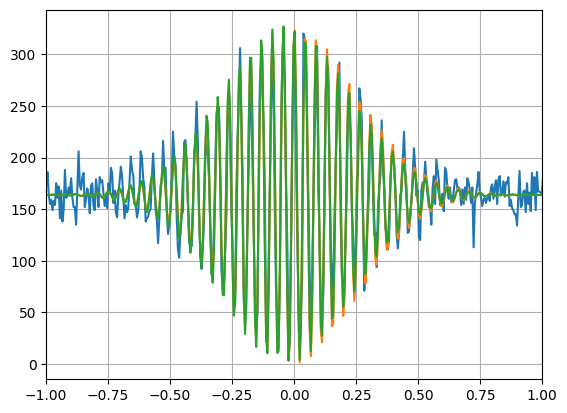

In [23]:
fig, axe = plt.subplots()
axe.plot(data['x'], data['y'])
axe.plot(data['x'], yhat)
axe.plot(data['x'], yhat2)
axe.set_xlim([-1, 1])
axe.grid()

In [11]:
x0lin = np.linspace(-0.25, 0.25, 500)

In [12]:
L = loss(x0lin)

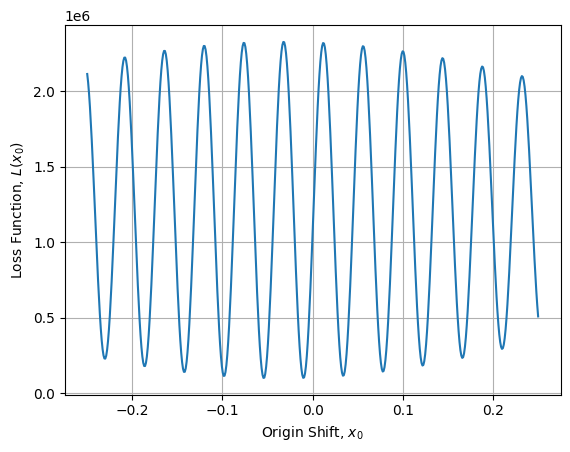

In [13]:
fig, axe = plt.subplots()
axe.plot(x0lin, L)
axe.set_xlabel(r"Origin Shift, $x_0$")
axe.set_ylabel("Loss Function, $L(x_0)$")
axe.grid()

In [14]:
def loss_factory_2(x, y, p):
    @np.vectorize
    def wrapped(phi, mu):
        return 0.5 * np.sum(np.power((y - model2(x, *p, phi, mu)), 2.))
    return wrapped

In [15]:
philin = np.linspace(-2 * np.pi, 2 * np.pi, 200)
mulin = np.linspace(-2, 2, 200)
Phi, Mu = np.meshgrid(philin, mulin)

In [16]:
loss2 = loss_factory_2(data['x'], data['y'], popt2[:-2])

In [17]:
L2 = loss2(Phi, Mu)

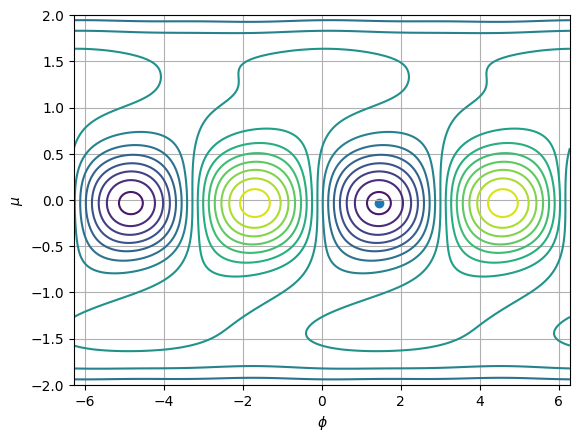

In [22]:
fig, axe = plt.subplots()
axe.contour(Phi, Mu, L2, 15)
axe.scatter(*popt2[-2:])
axe.set_xlabel(r"$\phi$")
axe.set_ylabel(r"$\mu$")
axe.grid()